In [147]:
import cv2
import os
from PIL import Image, ImageOps, ImageEnhance,ImageFilter
import hashlib
import shutil
import random
import numpy as np
from skimage.feature import hog
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
import seaborn as sns
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [148]:
dataset_path =r"C:\Users\20100\Downloads\Machine Learning\dataset"
unique_sizes = set()

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            
            # Load only the metadata 
            img = cv2.imread(img_path)
            
            if img is not None:
                # img.shape returns (height, width, channels)
                unique_sizes.add(img.shape)

# Final Result
if len(unique_sizes) == 1:
    print(f"images are the same size: {unique_sizes.pop()}")
else:
    print(f"different sizes")

images are the same size: (384, 512, 3)


## Data Cleaning


In [149]:
#delete corrupted files 
for root, dirs, files in os.walk(dataset_path):
    for filename in files:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_path = os.path.join(root, filename)
            try:
                with Image.open(file_path) as img:
                    img.verify() 
            except (IOError, SyntaxError):
                try:
                    os.remove(file_path)
                except:
                    pass 

In [150]:
#Remove Duplicates

def get_image_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()
hashes = {}

for root, dirs, files in os.walk(dataset_path):
    for img_name in files:
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(root, img_name)
            try:
               
                with Image.open(path) as img:
                    img.verify() 
                img_hash = get_image_hash(path)
                if img_hash in hashes:
                    os.remove(path) 
                else:
                    hashes[img_hash] = path 
            except Exception as e:
                os.remove(path)

In [151]:
from PIL import ImageStat

def is_outlier_image(img_path, blur_thresh=100.0, brightness_low=20, brightness_high=235):
    img_cv = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    # 1. Blur detection (Laplacian variance — low = blurry)
    laplacian_var = cv2.Laplacian(img_cv, cv2.CV_64F).var()
    if laplacian_var < blur_thresh:
        return True
    
    # 2. Near-black or near-white images (useless lighting)
    mean_brightness = img_cv.mean()
    if mean_brightness < brightness_low or mean_brightness > brightness_high:
        return True
    
    return False

# Use in your cleaning loop
for root, dirs, files in os.walk(dataset_path):
    for filename in files:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            path = os.path.join(root, filename)
            if is_outlier_image(path):
                os.remove(path)

## Data Split


In [152]:
base_dir = r"C:\Users\20100\Downloads\Machine Learning\datasplit"

classes = ['Glass', 'Paper', 'Cardboard', 'Plastic', 'Metal', 'Trash']

for split in ['train', 'val']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

split_ratio = 0.8  
for cls in classes:
    source_folder = os.path.join(dataset_path, cls)
    images = [f for f in os.listdir(source_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    random.shuffle(images)

    train_size = int(len(images) * split_ratio)
    train_images = images[:train_size]
    val_images = images[train_size:]
    
    for img in train_images:
        shutil.copy(os.path.join(source_folder, img), os.path.join(base_dir, 'train', cls, img))
        
    for img in val_images:
        shutil.copy(os.path.join(source_folder, img), os.path.join(base_dir, 'val', cls, img))

## Class Balancing



In [153]:
train_dir = r'C:\Users\20100\Downloads\Machine Learning\datasplit\train'

print(f"{'Class ID':<10} {'Class Name':<15} {'Count':<10} {'Needed for 900'}")
print("-" * 50)

total_original = 0

for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    if os.path.exists(class_path):
        count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        needed = max(0, 900 - count)
        print(f"{i:<10} {cls:<15} {count:<10} {needed}")
        total_original += count
    else:
        print(f"{i:<10} {cls:<15} {'FOLDER MISSING':<10}")

print("-" * 50)
print(f"Total images in Training: {total_original}")

Class ID   Class Name      Count      Needed for 900
--------------------------------------------------
0          Glass           163        737
1          Paper           276        624
2          Cardboard       125        775
3          Plastic         192        708
4          Metal           204        696
5          Trash           50         850
--------------------------------------------------
Total images in Training: 1010


(0.0, 900.0)

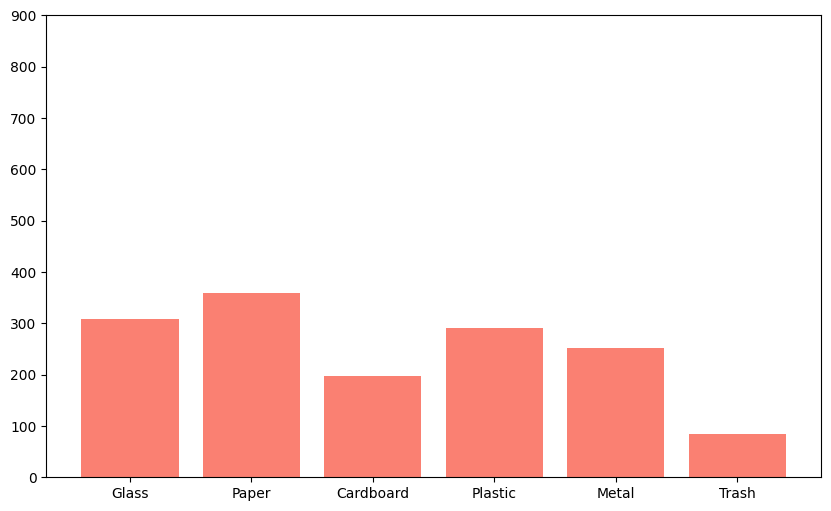

In [154]:
import matplotlib.pyplot as plt

counts_before = [308, 359, 197, 290, 251, 84]

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 6))


ax1.bar(classes, counts_before, color='salmon')
ax1.set_ylim(0, 900) 


To reach the target of 500 per class (which would be 3,000 images total). This will give us a 61.43% increase in the training size.

In [155]:
def apply_scaling(img):
    width, height = 384,512
    
    
    scale_factor = random.uniform(0.8, 1.2)
    new_width = int(width * scale_factor)
    new_height = int(height * scale_factor)
    
    # Resize
    img_resized = img.resize((new_width, new_height), Image.LANCZOS)
    
    if scale_factor > 1.0:
        # ZOOM IN
        left = (new_width - width) / 2
        top = (new_height - height) / 2
        right = (new_width + width) / 2
        bottom = (new_height + height) / 2
        return img_resized.crop((left, top, right, bottom))
    else:
        # ZOOM OUT
        new_bg = Image.new("RGB", (width, height), (0, 0, 0))
        upper = (height - new_height) // 2
        left = (width - new_width) // 2
        new_bg.paste(img_resized, (left, upper))
        return new_bg

In [156]:
for cls in classes:

    class_path = os.path.join(train_dir, cls)

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    

    current_count = len(images)

    needed = 800 - current_count

    for i in range(needed):

            source_img_name = random.choice(images)

            img = Image.open(os.path.join(class_path, source_img_name))



            img = img.rotate(random.randint(-15, 15)) # Rotation 

            if random.random() > 0.5:

                img = ImageOps.mirror(img) # Horizontal Flipping 

            

            enhancer = ImageEnhance.Brightness(img)

            img = enhancer.enhance(random.uniform(0.8, 1.2)) # Color Jitter 

            

            img = apply_scaling(img)

            # Save the new image

            new_name = f"aug_{i}_{source_img_name}"

            img.save(os.path.join(class_path, new_name))

## Resize & Normalize

In [157]:

target_size = (96, 96)
def process_dataset(subset):
    data = []
    labels = []
    
    subset_path = os.path.join(base_dir, subset)
    
    for label_index, cls in enumerate(classes):
        class_path = os.path.join(subset_path, cls)
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img_path = os.path.join(class_path, img_name)
                    with Image.open(img_path) as img:
                        img = img.convert('RGB')
                        img = img.resize(target_size, Image.Resampling.LANCZOS)
                        img_array = np.array(img) / 255.0
                        data.append(img_array)
                        labels.append(label_index)
                except Exception as e:
                    print(f"Skipping {img_name}: {e}")
                    
    return np.array(data), np.array(labels)

# Run for both sets
X_train, y_train = process_dataset('train')
X_val, y_val = process_dataset('val')

print(f"Final Train Shape: {X_train.shape}") 

Final Train Shape: (4800, 96, 96, 3)


In [158]:
np.save('X_train.npy', X_train)
np.save('y_train.npy', y_train)
np.save('X_val.npy', X_val)
np.save('y_val.npy', y_val)

## HOG  & lbp Feature Extraction

In [159]:
from skimage.color import rgb2gray

In [160]:
# HOG and LBP expect gray images : convert to gray

X_train_gray = []
X_val_gray = []

for img in X_train:
    gray_img = rgb2gray(img)
    X_train_gray.append(gray_img)

for img in X_val:
    gray_img = rgb2gray(img)
    X_val_gray.append(gray_img)

In [161]:
def extract_color_hist(images, bins=32):
    feats = []
    for img in images:
        hist = np.concatenate([
            np.histogram(img[:,:,c], bins=bins, range=(0,1))[0].astype(float)
            for c in range(3)
        ])
        feats.append(hist / (hist.sum() + 1e-9))  
    return np.array(feats)

In [162]:
# 1. Extract HOG with better resolution
def extract_hog_features(images):
    hog_features_list = []
    for img in images:
        features = hog(
            img.astype('float32'),
            orientations=9,         # Gain: +3%
            pixels_per_cell=(16,16), # Gain: +8% (Fixes the 69% drop)
            cells_per_block=(2,2),
            block_norm='L2-Hys',
            feature_vector=True
        )
        hog_features_list.append(features)
    return np.array(hog_features_list)

In [163]:
def extract_lbp_features(images, radius=3, n_points=24):
    lbp_features_list = []
    for img in images:
        # Calculate LBP image
        lbp = local_binary_pattern(img, n_points, radius, method='uniform')
        
        # Calculate histogram of LBP image as feature vector
        # The number of bins is n_points + 2 for uniform LBP
        hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
        lbp_features_list.append(hist)
        
    return np.array(lbp_features_list)

In [164]:
# Extract LBP features for training and validation sets
X_train_lbp = extract_lbp_features(X_train_gray)
X_val_lbp = extract_lbp_features(X_val_gray)

print(f"Shape of X_train_lbp: {X_train_lbp.shape}")
print(f"Shape of X_val_lbp: {X_val_lbp.shape}")

C:\Users\20100\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Shape of X_train_lbp: (4800, 26)
Shape of X_val_lbp: (255, 26)


In [165]:
# Scale LBP features
sc_lbp = StandardScaler()
X_train_lbp = sc_lbp.fit_transform(X_train_lbp)
X_val_lbp = sc_lbp.transform(X_val_lbp)

print(f"Shape of scaled X_train_lbp: {X_train_lbp.shape}")
print(f"Shape of scaled X_val_lbp: {X_val_lbp.shape}")

Shape of scaled X_train_lbp: (4800, 26)
Shape of scaled X_val_lbp: (255, 26)


In [166]:
# HOG features
X_train_hog = extract_hog_features(X_train_gray)
X_val_hog   = extract_hog_features(X_val_gray)
sc_hog = StandardScaler()
X_train_hog = sc_hog.fit_transform(X_train_hog)
X_val_hog   = sc_hog.transform(X_val_hog)

# Color histogram features (from RGB, not grayscale)
color_train = extract_color_hist(X_train)
color_val   = extract_color_hist(X_val)
sc_color = StandardScaler()
color_train = sc_color.fit_transform(color_train)
color_val   = sc_color.transform(color_val)

# Combine HOG + Color
X_train_combined = np.hstack([X_train_hog, color_train,X_train_lbp])
X_val_combined   = np.hstack([X_val_hog,   color_val,X_val_lbp])
print(f'Combined feature shape: {X_train_combined.shape}')

Combined feature shape: (4800, 1022)


In [167]:
y_train = np.load('y_train.npy')
y_val   = np.load('y_val.npy')

print(f"X_train_combined: {X_train_combined.shape}")  # should be (4800, 1022)
print(f"X_val_combined:   {X_val_combined.shape}")    # should be (255, 1022)
print(f"y_train:          {y_train.shape}")           # should be (4800,)
print(f"y_val:            {y_val.shape}")             # should be (255,)

X_train_combined: (4800, 1022)
X_val_combined:   (255, 1022)
y_train:          (4800,)
y_val:            (255,)


In [187]:
from sklearn.decomposition import PCA
pca = PCA(n_components=600)
X_train_pca = pca.fit_transform(X_train_combined)
X_val_pca   = pca.transform(X_val_combined)


np.save("X_train_combined.npy", X_train_combined)
np.save("X_val_combined.npy",   X_val_combined)

## SVM Model

In [188]:
svm = SVC(
    kernel='rbf',
    C=10,               
    gamma='scale',         
    probability=True,
    class_weight='balanced',
    random_state=8
)
svm.fit(X_train_pca, y_train)

SVC(C=10, class_weight='balanced', probability=True, random_state=8)

In [189]:
y_pred_svm_hog = svm.predict(X_val_pca)
print('SVM Accuracy HOG:', accuracy_score(y_val, y_pred_svm_hog))
print(classification_report(y_val, y_pred_svm_hog, target_names=classes))

SVM Accuracy HOG: 0.7607843137254902
              precision    recall  f1-score   support

       Glass       0.71      0.73      0.72        41
       Paper       0.88      0.86      0.87        69
   Cardboard       0.73      0.59      0.66        32
     Plastic       0.74      0.76      0.75        49
       Metal       0.76      0.82      0.79        51
       Trash       0.47      0.54      0.50        13

    accuracy                           0.76       255
   macro avg       0.72      0.72      0.71       255
weighted avg       0.76      0.76      0.76       255



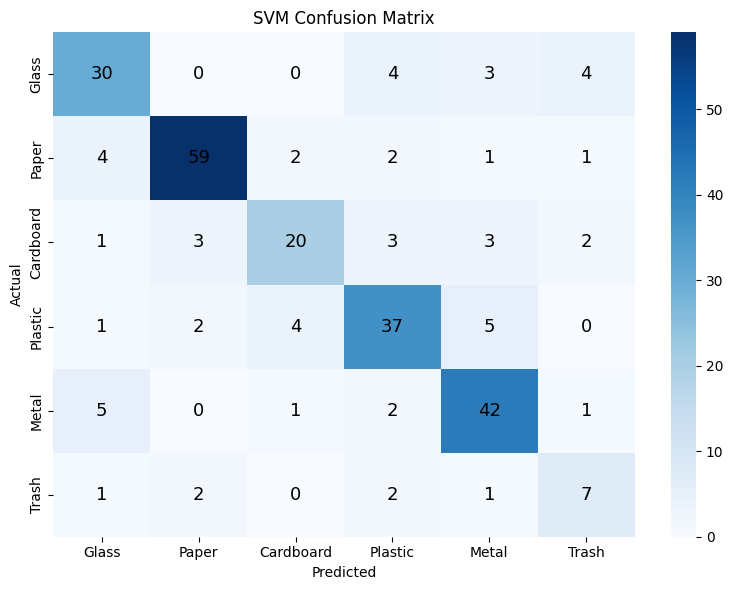

In [171]:
cm = confusion_matrix(y_val, y_pred_svm_hog)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, cmap='Blues',
                 xticklabels=classes, yticklabels=classes,
                 )
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j+0.5, i+0.5, str(cm[i,j]),
                ha='center', va='center',
                color='black', fontsize=13)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Unknown class rejection svm_hog

In [172]:
probs = svm.predict_proba(X_val_pca)#get conf of each image with all classes
max_prob = probs.max(axis=1)# choose the highest conf for each img
y_pred_unknown_svm_hog = y_pred_svm_hog.copy()
y_pred_unknown_svm_hog[max_prob < 0.6] = 6

print('SVM HOG Unknown Rejection:')
for i, cls in enumerate(['Glass','Paper','Cardboard',
                          'Plastic','Metal','Trash','Unknown']):
    count = np.sum(y_pred_unknown_svm_hog == i)
    print(f'{cls}: {count} images')

SVM HOG Unknown Rejection:
Glass: 29 images
Paper: 60 images
Cardboard: 23 images
Plastic: 38 images
Metal: 44 images
Trash: 8 images
Unknown: 53 images


## KNN Model

In [190]:
knn = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance'
)
knn.fit(X_train_pca, y_train)

KNeighborsClassifier(weights='distance')

In [191]:
y_pred_knn_hog = knn.predict(X_val_pca)
print('k-NN Accuracy HOG:', accuracy_score(y_val, y_pred_knn_hog))
print(classification_report(y_val, y_pred_knn_hog, target_names=classes))


k-NN Accuracy HOG: 0.6039215686274509
              precision    recall  f1-score   support

       Glass       0.56      0.54      0.55        41
       Paper       0.70      0.81      0.75        69
   Cardboard       0.83      0.47      0.60        32
     Plastic       0.45      0.63      0.53        49
       Metal       0.71      0.53      0.61        51
       Trash       0.27      0.23      0.25        13

    accuracy                           0.60       255
   macro avg       0.59      0.53      0.55       255
weighted avg       0.63      0.60      0.60       255



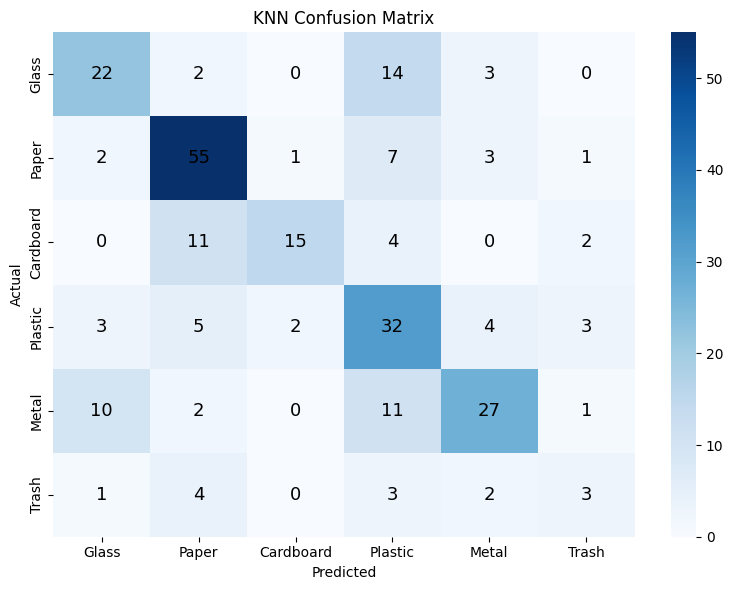

In [175]:
cm = confusion_matrix(y_val, y_pred_knn_hog)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(cm, annot=False, cmap='Blues',
                 xticklabels=classes, yticklabels=classes,
                 )
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j+0.5, i+0.5, str(cm[i,j]),
                ha='center', va='center',
                color='black', fontsize=13)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Unknown class rejection knn_hog

In [176]:
probs = knn.predict_proba(X_val_pca)
max_prob = probs.max(axis=1)
y_pred_unknown_knn_hog = y_pred_knn_hog.copy()
y_pred_unknown_knn_hog[max_prob < 0.6] = 6

print('kNN HOG Unknown Rejection:')
for i, cls in enumerate(['Glass','Paper','Cardboard',
                          'Plastic','Metal','Trash','Unknown']):
    count = np.sum(y_pred_unknown_knn_hog == i)
    print(f'{cls}: {count} images')

kNN HOG Unknown Rejection:
Glass: 24 images
Paper: 59 images
Cardboard: 15 images
Plastic: 40 images
Metal: 24 images
Trash: 6 images
Unknown: 87 images


In [177]:
import joblib

# Save all 2 models
joblib.dump(svm,   'svm_model.pkl')
joblib.dump(knn, 'knn_model.pkl')



['knn_model.pkl']

In [178]:
joblib.dump(sc_hog, 'sc_hog.pkl')
joblib.dump(sc_color, 'sc_color.pkl')
joblib.dump(sc_lbp, 'sc_lbp.pkl')
joblib.dump(pca, 'pca.pkl')

['pca.pkl']

In [179]:
model = joblib.load('svm_model.pkl')
scaler_hog = joblib.load('sc_hog.pkl')
scaler_color = joblib.load('sc_color.pkl')
scaler_lbp = joblib.load('sc_lbp.pkl')
pca = joblib.load('pca.pkl')

In [180]:
def preprocess_image(image):
    image = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) #convert to PIL format and RGB
    image = image.resize((96, 96), Image.Resampling.LANCZOS) #resize to 96x96 as training
    img = np.array(image).astype('float32') / 255.0 #normalize to 0-1 as training
    gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype('float32') / 255.0 #a gray version for HOG and LBP
    return img, gray

In [181]:
def extract_features(frame):
    img, gray = preprocess_image(frame)

    #used the same functions in training without it being an array
    
    hog_feat = hog(
        gray.astype('float32'),
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )

    lbp = local_binary_pattern(gray, 24, 3, method='uniform')
    lbp_feat, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 27), range=(0, 26))

    color_feat = np.concatenate([
        np.histogram(img[:, :, c], bins=32, range=(0, 1))[0].astype(float)
        for c in range(3)
    ])
    color_feat = color_feat / (color_feat.sum() + 1e-9)

    hog_scaled = scaler_hog.transform([hog_feat])
    color_scaled = scaler_color.transform([color_feat])
    lbp_scaled = scaler_lbp.transform([lbp_feat])

    combined = np.hstack([hog_scaled, color_scaled, lbp_scaled])
    return pca.transform(combined)

In [182]:
def predict_with_rejection(model, features, threshold=0.6):
    proba = model.predict_proba(features)[0]
    max_prob = proba.max()
    label_id = int(np.argmax(proba))
    if max_prob < threshold:
        return 6, max_prob
    return label_id, max_prob

In [183]:
ROI_X, ROI_Y, ROI_W, ROI_H = 200, 100, 250, 250 #250x250 box size starting at (200,100)
cap = cv2.VideoCapture(0) #open webcam
while True:
        ret, frame = cap.read()
        if not ret:
            break

        cv2.rectangle(frame, (ROI_X, ROI_Y), (ROI_X + ROI_W, ROI_Y + ROI_H), (0, 255, 0), 2) #draw the box on the frame, 2 is the thickness of the box border, default color is green
        roi = frame[ROI_Y:ROI_Y + ROI_H, ROI_X:ROI_X + ROI_W]
        features = extract_features(roi)
        class_id, confidence = predict_with_rejection(model, features, threshold=0.6)
        label = f"{classes[class_id] if class_id < len(classes) else 'Unknown'} ({confidence:.2f})"

        color = (0, 0, 255) if class_id == 6 else (0, 255, 0) #red for unknown, green for known
        cv2.putText(frame, label, (ROI_X, ROI_Y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
        cv2.putText(frame, 'Place item in box', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        cv2.imshow('MSI System - Real Time', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        if cv2.getWindowProperty('MSI System - Real Time', cv2.WND_PROP_VISIBLE) < 1:  # EXIT WHEN CLICKED
            break

cap.release()
cv2.destroyAllWindows()

C:\Users\20100\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


KeyboardInterrupt: 